# Bank Marketing — Data Understanding & EDA

## 1. Introduction

### 1.1 Objective & Scope

This notebook explores the UCI Bank Marketing dataset to establish
a reliable foundation for subsequent preprocessing and model development.

The main objectives are to:

- Inspect the dataset structure, variable types, and data quality.
- Identify potential data leakage and review feature availability.
- Establish a chronological train/validation/test split.
- Explore target distributions and feature relationships using training data.
- Document key findings and their implications for modeling.

The business objective is to prioritize customers by their predicted
probability of subscribing to a term deposit, allowing limited
call-center resources to focus on the most promising customers.

The prediction is made immediately before a planned marketing contact.

This notebook focuses on data understanding and exploratory analysis.
Preprocessing transformations and model training are handled in
subsequent notebooks.

### 1.2 Dataset Overview

The dataset contains records from direct marketing campaigns conducted
by a Portuguese banking institution.

Each row represents a marketing campaign observation associated with
a bank client.

The dataset contains:

- 41,188 observations
- 20 original input variables
- 1 binary target variable (`y`)

**Target variable**

- `yes`: The client subscribed to a term deposit.
- `no`: The client did not subscribe to a term deposit.

The input variables describe client characteristics, current campaign
information, previous campaign history, and macroeconomic conditions.

The dataset does not contain unique client identifiers, so repeated
observations from the same client cannot be directly identified.

An important limitation is that `duration`, the duration of the current
marketing contact, is only known after the contact occurs.

Therefore, `duration` will be retained in the raw dataset but excluded
from modeling features.

Detailed business requirements and the overall problem definition
are maintained in the project README.

## 2. Data Loading & Inspection

This section loads the raw dataset and examines its basic structure.

The objectives are to:

- Load the dataset from the project directory.
- Verify the dataset dimensions and sample observations.
- Inspect column names and data types.
- Identify numerical, categorical, and target columns.

Detailed data quality analysis and modeling feature selection
will be performed in subsequent sections.

### 2.1 Load Dataset

The dataset is loaded from the project's `data/raw/` directory.

The original CSV uses a semicolon (`;`) as the field separator.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

In [3]:
PROJECT_ROOT = Path.cwd().parent
PROJECT_ROOT

PosixPath('/home/moonk/projects/bank-marketing-ml')

In [4]:
RAW_DATA_PATH = (
    PROJECT_ROOT
     / "data"
     / "raw"
     / "bank-additional"
     / "bank-additional-full.csv"
    )

RAW_DATA_PATH

PosixPath('/home/moonk/projects/bank-marketing-ml/data/raw/bank-additional/bank-additional-full.csv')

In [5]:
df = pd.read_csv(RAW_DATA_PATH, sep=";")

In [6]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 2.2 Data Structure & Types

Inspect the dataset dimensions, column names, and data types.

This provides an initial understanding of the dataset schema
before performing detailed exploratory analysis.

In [7]:
df.shape

(41188, 21)

In [8]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [9]:
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

### 2.3 Initial Column Classification

Identify numerical and categorical columns based on their
original data types.

The target variable is `y`, which contains two categories:
`yes` and `no`.

This classification describes the raw dataset schema.

The final modeling feature set will be defined after reviewing
feature availability and potential data leakage in Section 3.

In [11]:
target = "y"

numeric_columns = df.select_dtypes(
    include="number"
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)
print("Target values:", df[target].unique())

Numeric columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
Target values: <StringArray>
['no', 'yes']
Length: 2, dtype: str


### 2.4 Initial Observations

The initial inspection confirms that:

- The dataset contains 41,188 observations and 21 columns.
- There are 20 original input variables and one target variable.
- The raw schema contains 10 numerical columns and 11 categorical
  columns, including the target.
- The target variable `y` represents binary subscription outcomes.
- The dataset contains client, campaign, historical, and
  macroeconomic information.
- `duration` remains in the raw dataset but is not eligible
  for modeling because it is unavailable at prediction time.

The next section reviews feature availability, potential
data leakage, and the chronological splitting strategy.

## 3. Data Leakage & Splitting Strategy

This section establishes the modeling feature set and data splitting strategy.

The objectives are to:

- Review feature availability at prediction time.
- Identify and exclude potential data leakage.
- Establish a chronological train/validation/test split.
- Verify the split sizes and temporal distribution characteristics.

### 3.1 Feature Availability & Data Leakage

The prediction is made immediately before a planned marketing contact.

Therefore, modeling features must be available at that point.

**Feature availability assumptions**

- Client characteristics and previous campaign history are available.
- Macroeconomic indicators are assumed to be available at prediction time.
- `month` and `day_of_week` are known from the planned contact date.
- `campaign` is available because the current contact attempt number is known.
- `contact` is available because the communication channel is determined before scoring.

**Excluded feature**

- `duration` records the duration of the current contact.
- It is only known after the contact occurs and therefore introduces data leakage.

The modeling feature set excludes `duration` while retaining all other
19 input variables.

These assumptions depend on the intended scoring workflow and must
be revisited if the operational prediction time changes.

In [12]:
target = "y"
excluded_features = ["duration"]

modeling_features = [
    col
    for col in df.columns
    if col not in [target, *excluded_features]
]

print(f"Modeling features: {len(modeling_features)}")
print(modeling_features)

Modeling features: 19
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


### 3.2 Chronological Splitting Strategy

The dataset exhibits temporal structure in its original row order.

Macroeconomic indicators and subscription rates change substantially
across chronological periods.

A random or stratified split would mix observations from different
temporal regimes across training and evaluation datasets.

To better approximate future deployment, the original chronological
order is preserved.

**Splitting strategy**

- Training: first 70% of observations
- Validation: next 20% of observations
- Test: final 10% of observations

The training set is used to fit preprocessing and model parameters.

The validation set is used for model comparison, hyperparameter tuning,
and model selection.

The test set is reserved for final evaluation after the model
configuration has been selected.

### 3.3 Train / Validation / Test Split

Split the dataset according to the established chronological boundaries.

The original row order is preserved, and no random shuffling is applied.

In [13]:
n = len(df)

train_end = int(n * 0.70)
valid_end = int(n * 0.90)

train_df = df.iloc[:train_end].copy()
valid_df = df.iloc[train_end:valid_end].copy()
test_df = df.iloc[valid_end:].copy()

### 3.4 Split Validation

Verify that:

- All observations are included exactly once.
- The chronological order is preserved.
- The resulting split sizes match the established strategy.
- The target distribution differs across development periods.

Temporal characteristics are examined to understand the limitations
of evaluating models across changing economic conditions.

In [14]:
split_summary = pd.DataFrame(
    {
        "Dataset": ["Train", "Validation", "Test"],
        "Rows": [
            len(train_df),
            len(valid_df),
            len(test_df),
        ],
    }
)

split_summary["Proportion"] = (
    split_summary["Rows"] / len(df)
)

assert split_summary["Rows"].sum() == len(df)
assert train_df.index.max() < valid_df.index.min()
assert valid_df.index.max() < test_df.index.min()

split_summary

,Dataset,Rows,Proportion
0,Train,28831,0.699985
1,Validation,8238,0.200010
2,Test,4119,0.100005


In [15]:
target_rates = pd.Series(
    {
        "Train": train_df[target].eq("yes").mean(),
        "Validation": valid_df[target].eq("yes").mean(),
    },
    name="Subscription Rate",
)

target_rates.to_frame()

,Subscription Rate
Train,0.055704
Validation,0.138626


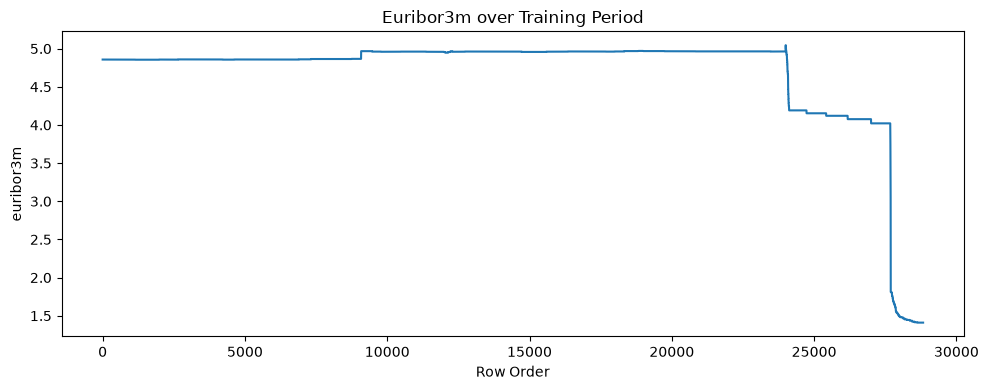

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(
    train_df.index,
    train_df["euribor3m"],
)

plt.xlabel("Row Order")
plt.ylabel("euribor3m")
plt.title("Euribor3m over Training Period")
plt.tight_layout()
plt.show()

### 3.5 Summary & Decisions

The following decisions are established for subsequent model development.

**Feature availability**

- The prediction time is immediately before a planned marketing contact.
- `duration` is excluded because it is unavailable at prediction time.
- The remaining 19 input variables are retained as candidate features.
- `campaign` and `contact` are retained under the established
  operational assumptions.

**Data splitting**

- A chronological 70/20/10 split is preserved.
- Training: 28,831 observations.
- Validation: 8,238 observations.
- Test: 4,119 observations.
- No random shuffling or stratification is applied.

**Temporal distribution shift**

- The dataset exhibits substantial temporal variation.
- Training and validation periods have different target prevalences.
- This shift must be considered when interpreting model performance.

**Data usage**

- Subsequent exploratory and preprocessing decisions will be based
  on the training data.
- Validation data will be used for model development and selection.
- From this point onward, the test set is frozen for final evaluation.

The next section performs exploratory data analysis using
the training set.

## 4. Exploratory Data Analysis (EDA)

This section examines the training data to identify characteristics
that may affect preprocessing, model development, and evaluation.

All modeling-oriented exploratory analysis is performed using
the training set only.

### 4.1 Data Quality Assessment

The objectives are to:

- Identify missing values and explicit unknown categories.
- Check for exact duplicate observations.
- Examine special values requiring domain-specific interpretation.

No observations or features are removed or transformed during this section.

In [17]:
numeric_features = (
    train_df[modeling_features]
    .select_dtypes(include="number")
    .columns.tolist()
)

categorical_features = (
    train_df[modeling_features]
    .select_dtypes(include=["object", "string", "category"])
    .columns.tolist()
)

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 9
Categorical features: 10


In [18]:
missing_counts = train_df.isna().sum()

print(f"Total missing values: {missing_counts.sum()}")

missing_counts[missing_counts > 0]

Total missing values: 0


Series([], dtype: int64)

In [19]:
unknown_counts = (
    train_df[categorical_features]
    .eq("unknown")
    .sum()
)

unknown_summary = pd.DataFrame({
    "count": unknown_counts,
    "rate": unknown_counts / len(train_df),
})

unknown_summary = (
    unknown_summary[unknown_summary["count"] > 0]
    .sort_values("rate", ascending=False)
)

unknown_summary

,count,rate
default,7302,0.253269
education,1183,0.041032
housing,694,0.024071
loan,694,0.024071
job,249,0.008637
marital,49,0.001700


In [20]:
duplicate_count = train_df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_count}")

Exact duplicate rows: 9


In [21]:
pdays_sentinel_rate = train_df["pdays"].eq(999).mean()

print(f"pdays = 999: {pdays_sentinel_rate:.2%}")

pdays = 999: 99.82%


In [22]:
pd.crosstab(
    train_df["previous"].gt(0),
    train_df["pdays"].eq(999),
    rownames=["Previous contacts > 0"],
    colnames=["pdays = 999"],
)

pdays = 999,False,True
Previous contacts > 0,,
False,0,27829
True,53,949


#### Observations

The data quality assessment identified the following findings:

**Missing values and unknown categories**

- No pandas-recognized missing values were found in the training data.
- Several categorical features contain the explicit category `"unknown"`.
- `default` has the largest unknown proportion (25.33%).
- Unknown categories will initially be retained as valid categories.

**Duplicate observations**

- Nine exact duplicate rows were identified.
- Because unique client identifiers are unavailable, it is not
  possible to reliably distinguish duplicate records from
  distinct observations with identical values.
- No duplicate observations are removed at this stage.

**Special values**

- `pdays` is dominated by the sentinel value `999` (approximately 99.82%).
- The sentinel value cannot be interpreted solely as an absence of
  previous campaign contacts.
- The relationship between `pdays`, `previous`, and `poutcome`
  requires careful interpretation.

No data cleaning or feature transformation is performed during EDA.

These findings will inform the preprocessing strategy in
`02_data_preprocessing.ipynb`.

### 4.2 Target Analysis

This section examines the distribution of the target variable `y`
in the training data.

The objectives are to:

- Examine class counts and proportions.
- Assess the degree of class imbalance.
- Identify implications for model evaluation.

The analysis is restricted to the training set.

In [24]:
target_counts = (
    train_df[target]
    .value_counts()
    .reindex(["no", "yes"], fill_value=0)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "proportion": target_counts / len(train_df),
})

target_summary

,count,proportion
y,,
no,27225,0.944296
yes,1606,0.055704


#### Observations

The training target distribution is strongly imbalanced.

- `no`: 27,225 observations (94.43%)
- `yes`: 1,606 observations (5.57%)

A classifier that always predicts `no` would achieve approximately
94.43% accuracy while failing to identify any potential subscribers.

Therefore, accuracy alone is not an appropriate metric for
model selection.

**Modeling implications**

- **Average Precision (AP)** will be the primary evaluation metric
  for positive-class ranking performance.
- **ROC-AUC** will be used to assess overall ranking discrimination.
- **Precision@K, Recall@K, and Lift@K** will evaluate how effectively
  the model prioritizes customers under limited contact capacity.
- Accuracy may be reported as a reference metric but will not
  drive model selection.

The positive-class prevalence of 5.57% also provides a reference
level for interpreting Average Precision and Lift under the
training distribution.

Because target prevalence varies across chronological periods,
validation performance must be interpreted in the context of
temporal distribution shift.

### 4.3 Feature Distributions

This section examines the distributions of numerical and categorical
modeling features in the training data.

The objectives are to:

- Identify skewed distributions and extreme values.
- Examine dominant and rare categorical values.
- Identify distributional characteristics relevant to preprocessing.
- Understand potential limitations of the feature representations.

No outlier removal, category merging, or feature transformation
is performed during EDA.

#### 4.3.1 Numerical Features

Numerical features are examined using descriptive statistics,
selected quantiles, and representative distribution plots.

Particular attention is given to skewed variables, extreme values,
and features with highly concentrated distributions.

In [25]:
numeric_summary = (
    train_df[numeric_features]
    .describe(percentiles=[0.50, 0.95, 0.99])
    .T[["min", "50%", "95%", "99%", "max"]]
)

numeric_summary["unique_values"] = (
    train_df[numeric_features].nunique()
)

numeric_summary

,min,50%,95%,99%,max,unique_values
age,18.000,39.000,57.000,59.000,95.000,63
campaign,1.000,2.000,8.000,17.000,56.000,42
pdays,0.000,999.000,999.000,999.000,999.000,13
previous,0.000,0.000,0.000,1.000,3.000,4
emp.var.rate,-1.800,1.400,1.400,1.400,1.400,5
cons.price.idx,92.756,93.918,94.465,94.465,94.465,9
cons.conf.idx,-50.000,-41.800,-36.100,-36.100,-36.100,9
euribor3m,1.410,4.957,4.967,4.968,5.045,93
nr.employed,5099.100,5228.100,5228.100,5228.100,5228.100,5


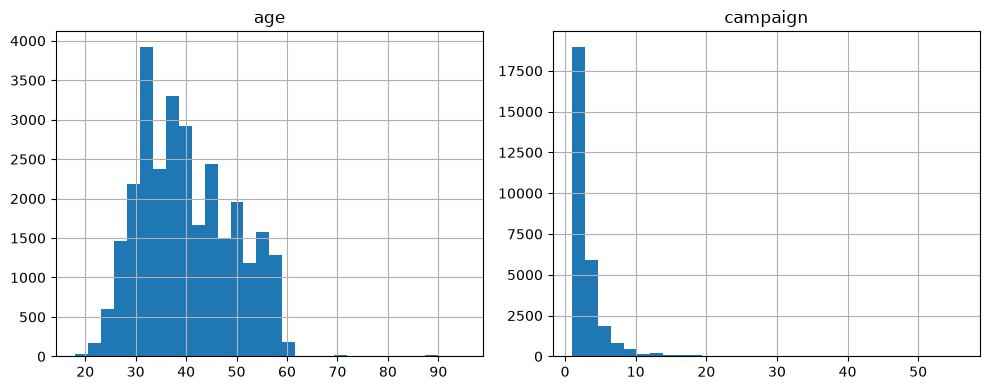

In [26]:
train_df[["age", "campaign"]].hist(
    bins=30,
    figsize=(10, 4),
)

plt.tight_layout()
plt.show()

In [27]:
train_df["previous"].value_counts(
    normalize=True
).sort_index().rename("proportion").to_frame()

,proportion
previous,
0,0.965246
1,0.033679
2,0.001006
3,0.000069


#### 4.3.2 Categorical Features

Categorical features are examined to identify:

- The number of observed categories.
- Dominant categories.
- Categories with very low frequencies.
- Potential issues related to categorical encoding.

Rare categories are identified for inspection only.
No categories are merged or removed at this stage.

In [28]:
categorical_summary = []

for col in categorical_features:
    proportions = train_df[col].value_counts(normalize=True)

    categorical_summary.append({
        "feature": col,
        "n_categories": len(proportions),
        "top_category": proportions.index[0],
        "top_share": proportions.iloc[0],
        "rare_categories_below_1pct": (proportions < 0.01).sum(),
    })

categorical_summary = (
    pd.DataFrame(categorical_summary)
    .set_index("feature")
    .sort_values("n_categories", ascending=False)
)

categorical_summary

,n_categories,top_category,top_share,rare_categories_below_1pct
feature,,,,
job,12,admin.,0.246505,2
month,9,may,0.269259,3
education,8,university.degree,0.289445,1
day_of_week,5,thu,0.211196,0
marital,4,married,0.631404,1
default,3,no,0.746627,1
loan,3,no,0.824599,0
housing,3,yes,0.508099,0
poutcome,3,nonexistent,0.965246,1


In [29]:
for col in ["default", "month", "poutcome"]:
    print(f"\n--- {col} ---")

    print(
        train_df[col]
        .value_counts(normalize=True)
        .round(4)
    )


--- default ---
default
no         0.7466
unknown    0.2533
yes        0.0001
Name: proportion, dtype: float64

--- month ---
month
may    0.2693
jul    0.2319
aug    0.1795
jun    0.1517
nov    0.1254
apr    0.0298
mar    0.0098
oct    0.0023
dec    0.0003
Name: proportion, dtype: float64

--- poutcome ---
poutcome
nonexistent    0.9652
failure        0.0330
success        0.0017
Name: proportion, dtype: float64


#### Observations

**Numerical features**

- `age` is moderately right-skewed, with a median of 39 and
  a maximum of 95.
- `campaign` is strongly right-skewed, with a median of 2,
  a 99th percentile of 17, and a maximum of 56.
- `previous` is highly concentrated at zero, with approximately
  95% of observations having no previous campaign contacts.
- `pdays` is dominated by the sentinel value `999`, as examined
  in Section 4.1.
- Several macroeconomic features have relatively few unique values,
  reflecting the economic regimes represented in the training period.

**Categorical features**

- Categorical features generally have low cardinality.
- `default` contains a large `"unknown"` group (25.33%) and
  an extremely rare `yes` category.
- `month` has an uneven distribution, with only 9 categories
  observed in the training period.
- `poutcome` is dominated by `nonexistent` (96.52%).
- Several categorical features contain rare categories,
  but none are removed or merged during EDA.

**Modeling implications**

- Numerical features have different scales and distributional
  characteristics, which should be considered during preprocessing.
- Categorical encoding must support categories not observed
  during training.
- Dominant and rare categories may affect model estimation
  and interpretation.
- Extreme values and skewed distributions do not automatically
  justify clipping, removal, or transformation.
- Potential preprocessing alternatives should be evaluated
  using validation performance rather than distributional
  characteristics alone.

### 4.4 Feature-Target Relationships

This section examines associations between modeling features and
the target variable using the training data.

The objectives are to:

- Identify features associated with subscription outcomes.
- Compare subscription rates across selected categorical features.
- Examine numerical feature differences between target classes.
- Assess the reliability of observed relationships based on sample sizes.
- Identify relationships that require cautious interpretation.

These analyses describe associations, not causal effects or
model-based feature importance.

No features are selected or removed based solely on these results.

#### 4.4.1 Categorical Features vs Target

Subscription rates are compared across selected categorical features.

Both category counts and subscription rates are reported because
high observed rates in small groups may be statistically unstable.

The selected features represent client characteristics,
contact information, temporal context, and campaign history.

In [30]:
train_analysis = train_df.assign(
    y_yes=train_df[target].eq("yes").astype(int)
)

selected_categorical = [
    "job",
    "contact",
    "month",
    "poutcome",
]

for col in selected_categorical:
    summary = (
        train_analysis
        .groupby(col)["y_yes"]
        .agg(
            count="size",
            subscribers="sum",
            subscription_rate="mean",
        )
        .sort_values("subscription_rate", ascending=False)
    )

    print(f"\n--- {col} ---")
    display(summary)


--- job ---


,count,subscribers,subscription_rate
job,,,
student,237,33,0.139241
retired,879,81,0.092150
management,2096,127,0.060592
self-employed,1043,62,0.059444
admin.,7107,416,0.058534
entrepreneur,1105,60,0.054299
technician,5054,271,0.053621
unknown,249,13,0.052209
services,2826,143,0.050602



--- contact ---


,count,subscribers,subscription_rate
contact,,,
cellular,15038,1051,0.069890
telephone,13793,555,0.040238



--- month ---


,count,subscribers,subscription_rate
month,,,
oct,67,42,0.626866
mar,282,126,0.446809
apr,859,141,0.164144
dec,10,1,0.100000
jul,6685,407,0.060883
nov,3616,190,0.052544
aug,5175,271,0.052367
jun,4374,188,0.042981
may,7763,240,0.030916



--- poutcome ---


,count,subscribers,subscription_rate
poutcome,,,
success,50,7,0.140000
failure,952,56,0.058824
nonexistent,27829,1543,0.055446


#### 4.4.2 Numerical Features vs Target

Selected numerical features are compared across the two target classes
using their means and medians.

The analysis focuses on client characteristics, campaign activity,
and macroeconomic context.

Because `pdays` is dominated by a sentinel value, it is
examined separately rather than interpreted as an ordinary
continuous variable.

In [31]:
selected_numeric = [
    "age",
    "campaign",
    "previous",
    "euribor3m",
    "nr.employed",
]

numeric_target_summary = (
    train_analysis
    .groupby(target)[selected_numeric]
    .agg(["mean", "median"])
    .T
)

numeric_target_summary

y                            no          yes
age         mean      40.218329    39.485056
            median    39.000000    37.000000
campaign    mean       2.785308     2.479452
            median     2.000000     2.000000
previous    mean       0.035556     0.041719
            median     0.000000     0.000000
euribor3m   mean       4.709733     4.274133
            median     4.957000     4.957000
nr.employed mean    5209.595581  5196.411083
            median  5228.100000  5228.100000

In [32]:
pdays_target_summary = (
    train_analysis
    .assign(pdays_is_999=train_analysis["pdays"].eq(999))
    .groupby("pdays_is_999")["y_yes"]
    .agg(
        count="size",
        subscribers="sum",
        subscription_rate="mean",
    )
)

pdays_target_summary

,count,subscribers,subscription_rate
pdays_is_999,,,
False,53,8,0.150943
True,28778,1598,0.055529


#### 4.4.3 Observations

**Categorical features**

- `job` shows differences in subscription rates across occupations.
  `student` and `retired` have relatively high rates in the training period.
- `contact` shows a noticeable difference between `cellular` (6.99%)
  and `telephone` (4.02%).
- `month` shows substantial variation in subscription rates,
  but these differences are closely related to temporal conditions.
- `poutcome = success` has a relatively high subscription rate (14.00%),
  although the category contains only 50 training observations.

**Numerical features**

- `age`, `campaign`, and `previous` show relatively modest
  differences between target classes.
- Several macroeconomic features, particularly `euribor3m`
  and `nr.employed`, show noticeable differences between
  the two target classes.
- These macroeconomic relationships may reflect changes in
  economic conditions across chronological periods.
- Observations with `pdays != 999` have a higher subscription rate,
  but the group contains only 53 training observations.

**Modeling implications**

- Several features exhibit associations with subscription outcomes.
- Small category sizes can produce unstable subscription-rate estimates.
- Temporal variables and macroeconomic indicators may capture
  overlapping information about economic regimes.
- Univariate associations do not establish causal effects or
  predictive importance in a multivariate model.
- No features are selected or removed based solely on these findings.

The usefulness of individual features and feature combinations
will be evaluated through validation-based modeling experiments.

### 4.5 Feature Relationships

This section examines relationships among selected modeling features
using the training data.

The objectives are to:

- Identify strong correlations among macroeconomic variables.
- Examine structural relationships among previous campaign features.
- Understand potential redundancy and implications for modeling.

Strong feature relationships do not automatically justify
feature removal.

Their impact will be evaluated during model development.

#### 4.5.1 Macroeconomic Feature Correlations

Macroeconomic indicators may capture overlapping information
about economic conditions and temporal regimes.

Pearson correlations are examined to identify strongly related
variables and assess potential multicollinearity.

High correlation does not necessarily imply that a feature
should be removed.

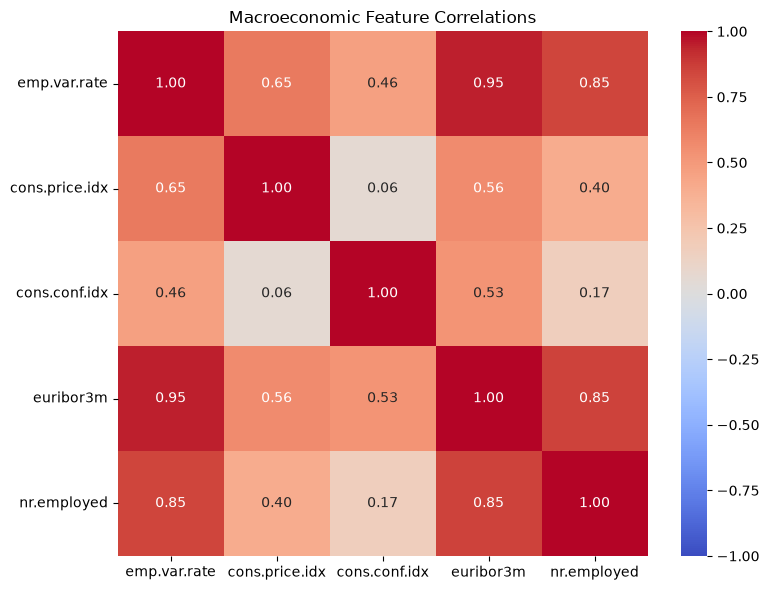

In [33]:
import seaborn as sns

macro_features = [
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed",
]

macro_corr = train_df[macro_features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    macro_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)

plt.title("Macroeconomic Feature Correlations")
plt.tight_layout()
plt.show()

#### 4.5.2 Previous Campaign History Relationships

The features `previous` and `poutcome` describe different aspects
of previous marketing campaign activity.

- `previous` records the number of contacts performed before
  the current campaign.
- `poutcome` records the outcome of the previous campaign.

A contingency table is used to examine whether these features
encode overlapping information.

In [34]:
history_summary = pd.crosstab(
    train_df["poutcome"],
    train_df["previous"].gt(0),
    rownames=["Previous Campaign Outcome"],
    colnames=["Has Previous Contacts"],
)

history_summary

Has Previous Contacts,False,True
Previous Campaign Outcome,,
failure,0,952
nonexistent,27829,0
success,0,50


#### 4.5.3 Observations

**Macroeconomic feature relationships**

- Strong positive correlations are observed among several
  macroeconomic indicators.
- `emp.var.rate` and `euribor3m` have the strongest observed
  correlation (approximately 0.95).
- `euribor3m` and `nr.employed`, as well as `emp.var.rate`
  and `nr.employed`, are also strongly correlated
  (approximately 0.85).
- These relationships suggest that the variables capture
  overlapping aspects of economic and temporal conditions.

**Previous campaign history**

- `previous` and `poutcome` exhibit a strong structural relationship.
- `poutcome = nonexistent` corresponds to no previous campaign
  contacts in the training data.
- Although related, these features contain distinct information
  about contact frequency and previous campaign outcomes.
- `pdays` is another related feature, with its sentinel structure
  examined in Section 4.1.

**Modeling implications**

- Strongly correlated features may affect coefficient stability
  and interpretation in linear models.
- Correlated features may still provide useful predictive information.
- The relationships among macroeconomic variables should be
  considered alongside temporal distribution shift.
- No features are removed solely because of correlation
  or structural association.
- Feature redundancy and predictive usefulness will be evaluated
  through validation-based modeling experiments.

## 5. Findings & Summary

This notebook established the data understanding, feature availability
assumptions, and splitting strategy for the Bank Marketing classification task.

Exploratory analysis was conducted using the training data to identify
characteristics relevant to subsequent preprocessing and model development.

### 5.1 Key Findings

**Data structure and quality**

- The dataset contains 41,188 observations, 20 original input variables,
  and one binary target variable (`y`).
- No pandas-recognized missing values were found in the training data.
- Several categorical features contain explicit `"unknown"` values,
  particularly `default` (25.33%).
- Nine exact duplicate observations were identified but retained
  because unique client identifiers are unavailable.
- `pdays` is dominated by the sentinel value `999` (approximately 99.82%),
  which requires careful interpretation.

**Target distribution**

- The training set is strongly imbalanced, with a subscription rate of 5.57%.
- Target prevalence differs substantially across chronological periods.
- Accuracy alone is insufficient for evaluating models intended to
  identify and prioritize potential subscribers.

**Feature characteristics**

- Numerical features exhibit different scales, skewness, and degrees
  of concentration.
- Categorical features generally have low cardinality, although
  some contain dominant or rare categories.
- Several features show associations with subscription outcomes,
  but these relationships do not establish causality or predictive importance.
- Macroeconomic variables exhibit strong correlations and capture
  overlapping temporal and economic information.
- Previous campaign features (`pdays`, `previous`, `poutcome`)
  contain structurally related but non-identical information.

### 5.2 Modeling Decisions

**Feature availability**

- Predictions are generated immediately before a planned marketing contact.
- `duration` is excluded because it is unavailable at prediction time.
- The remaining 19 input variables are retained as candidate features.
- `campaign` and `contact` are retained under the established
  operational assumptions.

**Data splitting**

- The chronological 70/20/10 split is preserved:
  - Training: 28,831 observations
  - Validation: 8,238 observations
  - Test: 4,119 observations
- Training data is used to fit preprocessing and model parameters.
- Validation data is used for model development and selection.
- From this point onward, the test set is frozen for final evaluation.

**Preprocessing considerations**

- Numerical and categorical features require appropriate preprocessing.
- `"unknown"` values will initially remain explicit categories.
- Categorical encoding must handle categories not observed during training.
- The sentinel structure of `pdays` must be considered when evaluating
  alternative feature representations.
- Rare categories, extreme values, and correlated features will not
  be automatically removed or transformed.
- All learned preprocessing must be fitted on training data only.

**Evaluation strategy**

- Average Precision (AP) is the primary model-selection metric.
- ROC-AUC provides an additional measure of ranking discrimination.
- Precision@K, Recall@K, and Lift@K assess business-oriented
  customer prioritization under limited contact capacity.
- Accuracy is treated as a reference metric rather than a
  primary selection criterion.
- Temporal distribution shift must be considered when interpreting
  validation performance.

### 5.3 Next Steps

The next notebook, `02_data_preprocessing.ipynb`, will:

1. Reproduce the established chronological data split.
2. Define numerical, categorical, and special feature groups.
3. Establish baseline preprocessing strategies.
4. Evaluate appropriate representations for special features
   such as `pdays`.
5. Construct and validate a reproducible preprocessing pipeline.

Preprocessing decisions will be evaluated using training and
validation data without using the test set.

The resulting preprocessing configuration will provide the foundation
for baseline modeling and subsequent experiments.